# pre-processing anndata object

In [1]:
import scanpy as sc
import anndata
from scipy import io
from scipy.sparse import coo_matrix, csr_matrix
import numpy as np
import os
import pandas as pd

In [2]:
# load sparse matrix:
X = io.mmread("counts.mtx")

In [3]:
# create anndata object
adata = anndata.AnnData(
    X=X.transpose().tocsr()
)

/home/zhj869/.conda/envs/velocyto_test/lib/python3.7/site-packages/ipykernel_launcher.py:3: FutureWarning: X.dtype being converted to np.float32 from int64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  This is separate from the ipykernel package so we can avoid doing imports until


In [4]:
# load cell metadata:
cell_meta = pd.read_csv("metadata.csv")

In [5]:
# load gene names:
with open("gene_names.csv", 'r') as f:
    gene_names = f.read().splitlines()

In [6]:
# set anndata observations and index obs by barcodes, var by gene names
adata.obs = cell_meta
adata.obs.index = adata.obs['barcode']
adata.var.index = gene_names


In [7]:
# load dimensional reduction:
pca = pd.read_csv("pca.csv")
pca.index = adata.obs.index

In [8]:
# set pca and umap
adata.obsm['X_pca'] = pca.to_numpy()
adata.obsm['X_umap'] = np.vstack((adata.obs['UMAP_1'].to_numpy(), adata.obs['UMAP_2'].to_numpy())).T

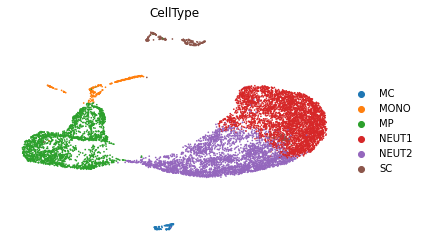

In [9]:
# plot a UMAP colored by seurat clusters to test:
sc.pl.umap(adata, color=['CellType'], frameon=False, save=True)

In [10]:
# save dataset as anndata format
adata.write('Axin2_combined.h5ad')

# Load data

In [11]:
import scvelo as scv
import scanpy as sc
import cellrank as cr
import numpy as np
import pandas as pd
import anndata as ad

In [12]:
scv.settings.verbosity = 3
scv.settings.set_figure_params('scvelo', facecolor='white', dpi=100, frameon=False)
cr.settings.verbosity = 2

In [13]:
# reload dataset
adata = sc.read_h5ad('Axin2_combined.h5ad')

In [14]:
# load loom files for spliced/unspliced matrices for each sample:
ldata1 = scv.read('Axin2_1.loom', cache=True)
ldata2 = scv.read('Axin2_2.loom', cache=True)

/home/zhj869/.conda/envs/velocyto_test/lib/python3.7/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/zhj869/.conda/envs/velocyto_test/lib/python3.7/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [15]:
# rename barcodes in order to merge:
barcodes = [bc.split(':')[1] for bc in ldata1.obs.index.tolist()]
barcodes = [bc[0:len(bc)-1] + '_10' for bc in barcodes]
ldata1.obs.index = barcodes

In [16]:
barcodes = [bc.split(':')[1] for bc in ldata2.obs.index.tolist()]
barcodes = [bc[0:len(bc)-1] + '_11' for bc in barcodes]
ldata2.obs.index = barcodes

In [17]:
# make variable names unique
ldata1.var_names_make_unique()
ldata2.var_names_make_unique()

In [18]:
# concatenate the three loom
ldata = ldata1.concatenate([ldata2])

In [19]:
# merge matrices into the original adata object
adata = scv.utils.merge(adata, ldata)

In [20]:
adata

AnnData object with n_obs × n_vars = 10594 × 17648
    obs: 'orig.ident', 'nUMI', 'nGene', 'log10GenesPerUMI', 'mitoRatio', 'cells', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'integrated_snn_res.0.1', 'seurat_clusters', 'barcode', 'UMAP_1', 'UMAP_2', 'CellType', 'CellType_cluster', 'sample_batch', 'batch', 'initial_size_spliced', 'initial_size_unspliced', 'initial_size'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    uns: 'CellType_colors'
    obsm: 'X_pca', 'X_umap'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'

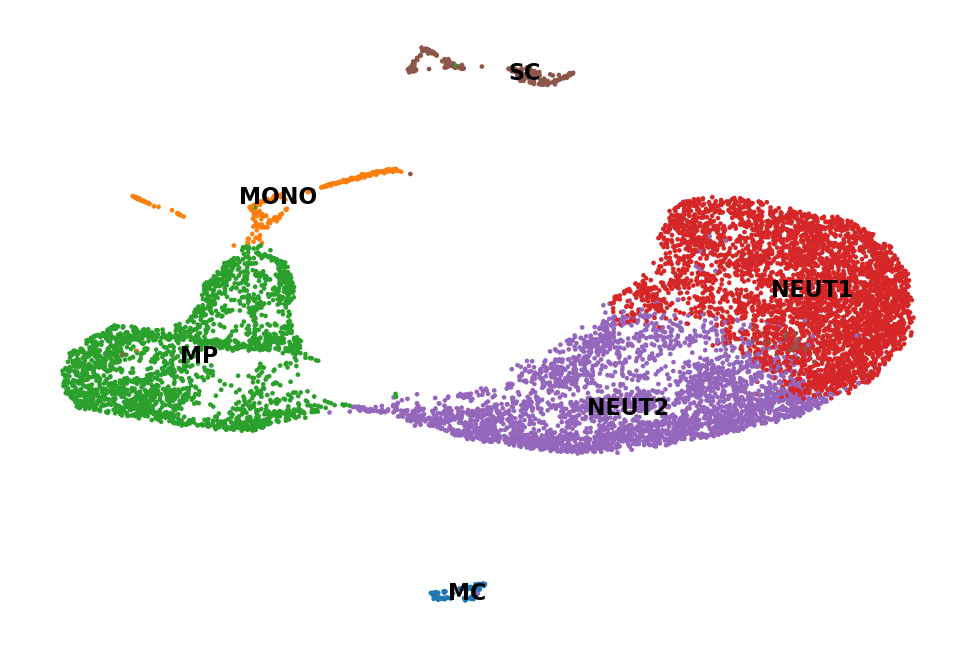

In [21]:
# plot umap to check
sc.pl.umap(adata, color='CellType', frameon=False, legend_loc='on data', legend_fontsize=8, title='', save='_celltypes.pdf')

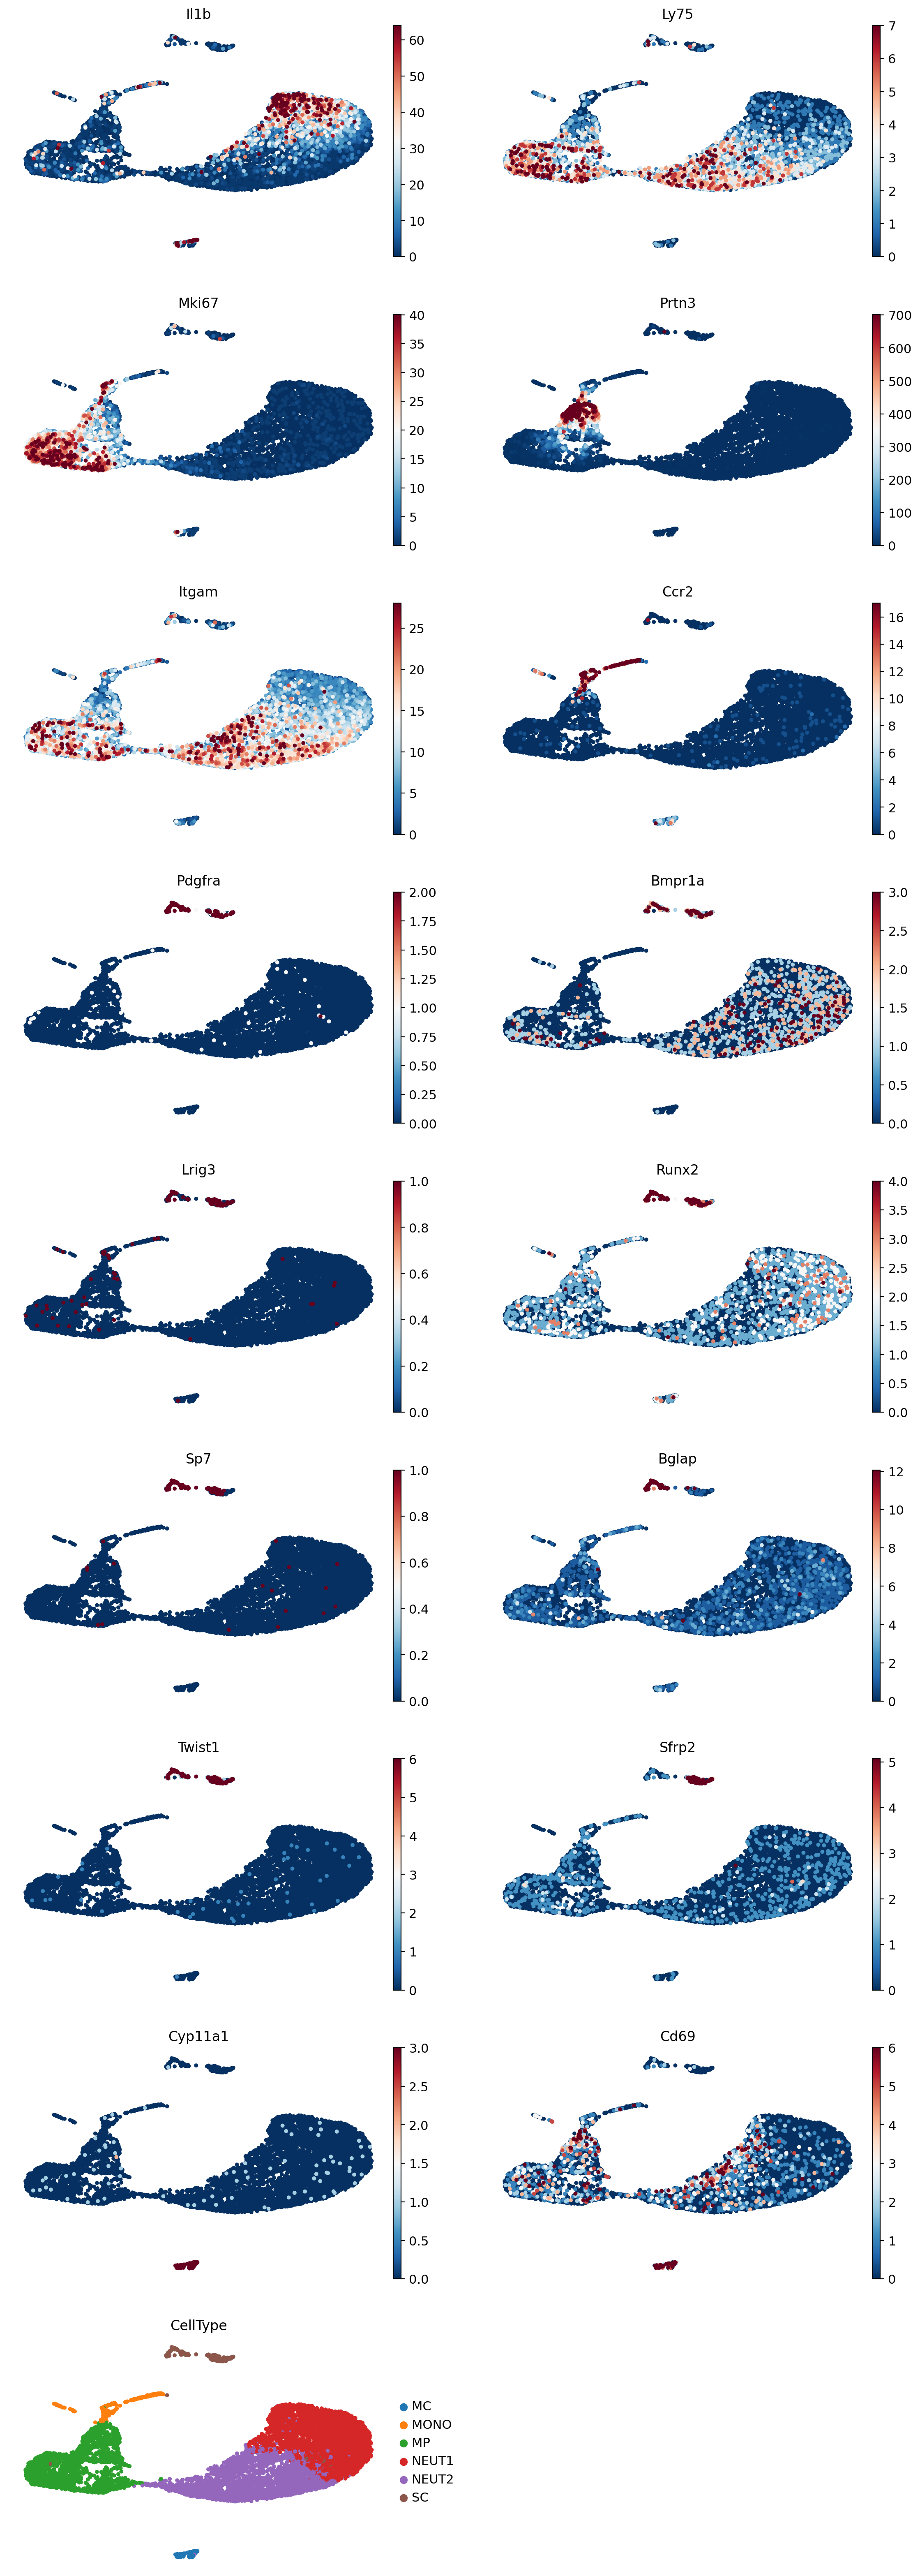

In [22]:
 sc.pl.umap(adata, color=['Il1b','Ly75','Mki67','Prtn3','Itgam','Ccr2','Pdgfra','Bmpr1a', 'Lrig3', 'Runx2', 'Sp7','Bglap','Twist1','Sfrp2','Cyp11a1', 'Cd69','CellType'], 
               s=50, frameon=False, ncols=2, vmax='p99')

# Computing RNA velocity using scVelo

saving figure to file ./figures/scvelo_proportions_proportions.pdf


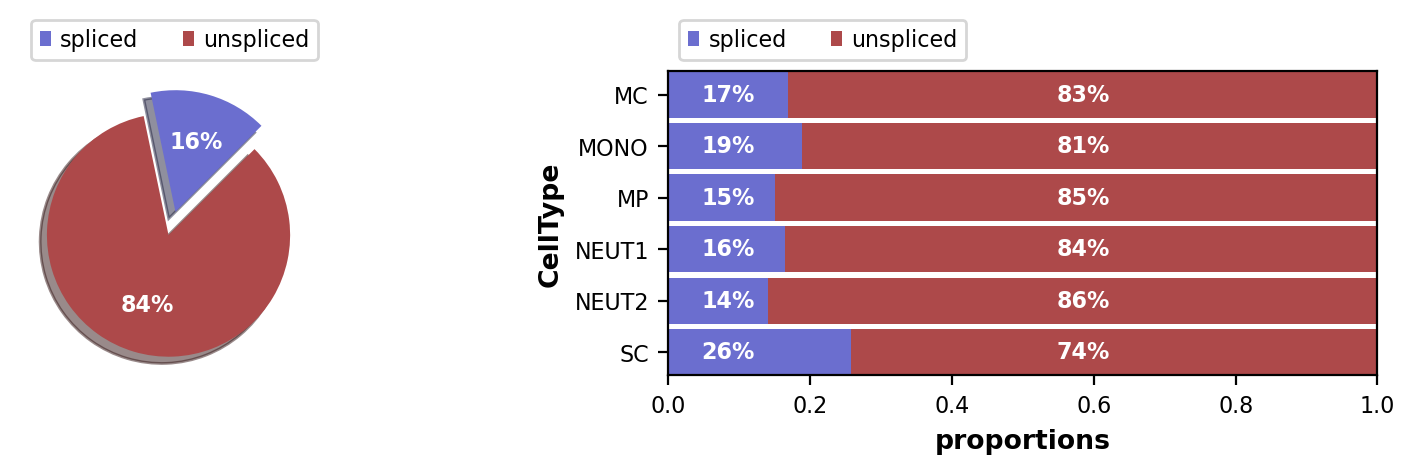

In [23]:
scv.pl.proportions(adata, groupby='CellType', save='proportions.pdf')

In [24]:
# pre-process
scv.pp.filter_and_normalize(adata)
scv.pp.moments(adata)

Normalized count data: X, spliced, unspliced.
computing neighbors
    finished (0:00:26) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:06) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [25]:
# compute velocity
scv.tl.velocity(adata, mode='stochastic')
scv.tl.velocity_graph(adata)

computing velocities
    finished (0:00:38) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/32 cores)


  0%|          | 0/10594 [00:00<?, ?cells/s]

/home/zhj869/.conda/envs/velocyto_test/lib/python3.7/site-packages/scvelo/core/_parallelize.py:138: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  res = np.array(res) if as_array else res


    finished (0:01:09) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


# Visualize velocity fields

computing velocity embedding
    finished (0:00:05) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
saving figure to file ./figures/scvelo_embedding.pdf


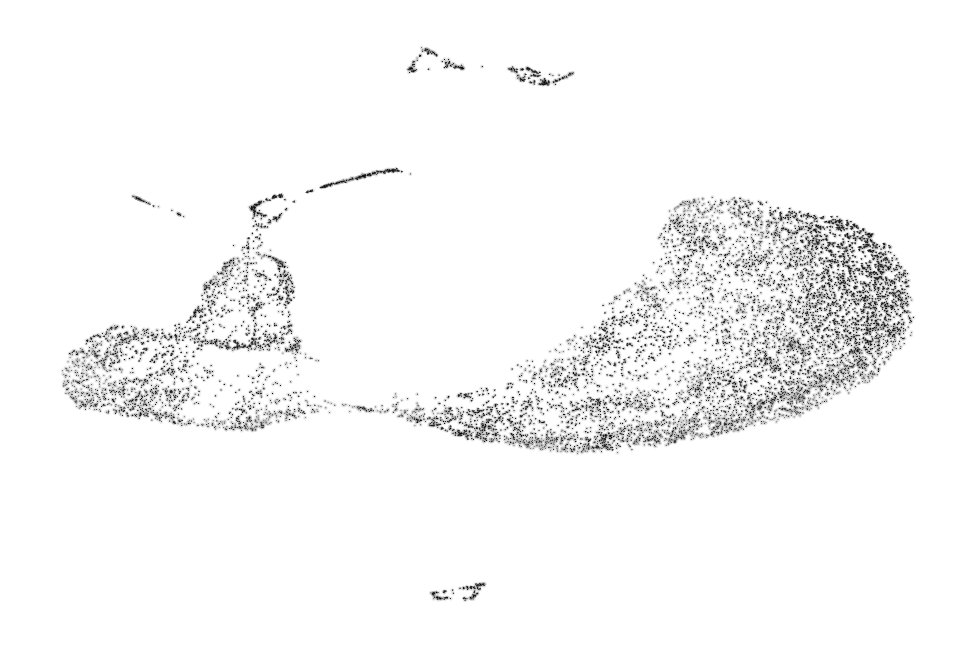

In [26]:
scv.pl.velocity_embedding(adata, basis='umap', frameon=False, save='embedding.pdf')


saving figure to file ./figures/scvelo_embedding_grid.pdf


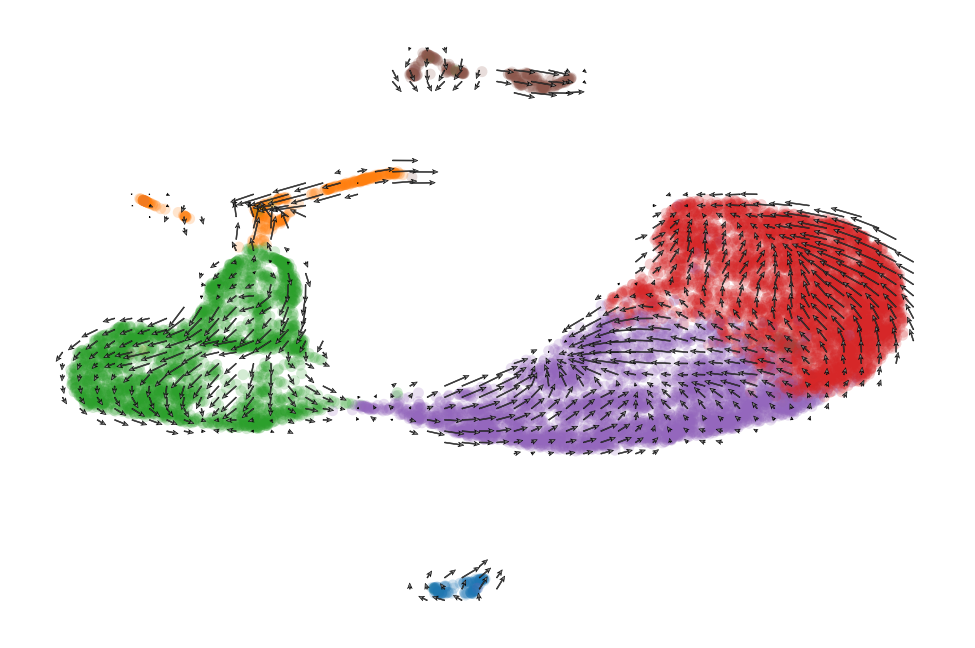

In [27]:
scv.pl.velocity_embedding_grid(adata, basis='umap', color='CellType', save='embedding_grid.pdf', title='', scale=0.25)


figure cannot be saved as pdf, using png instead.
saving figure to file ./figures/scvelo_embedding_stream.png


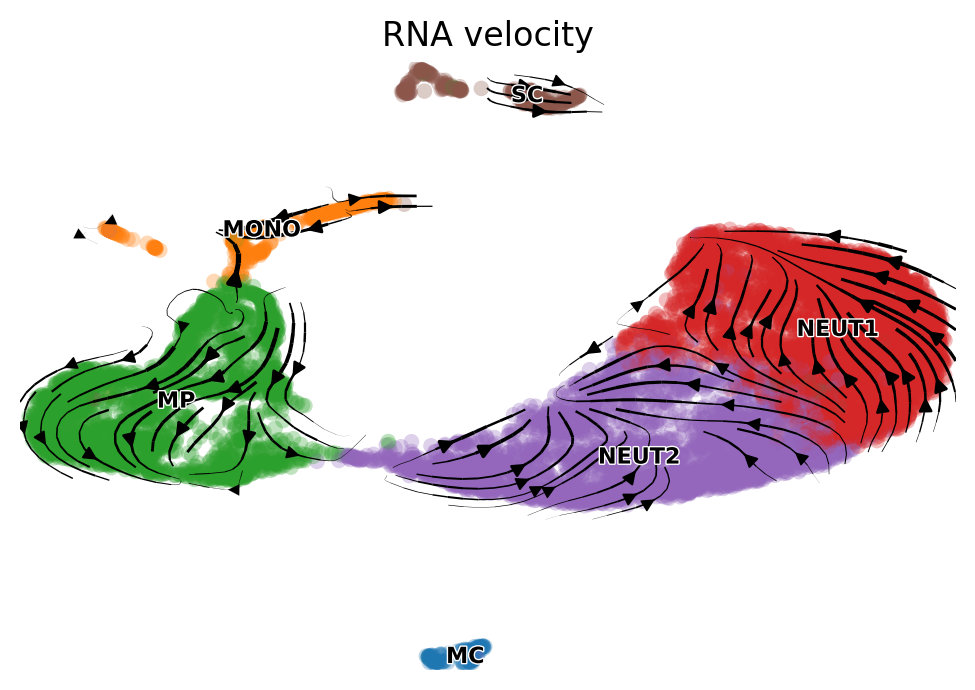

In [28]:
scv.pl.velocity_embedding_stream(adata, basis='umap', color=['CellType'],legend_fontsize=8, save='embedding_stream.pdf', title='RNA velocity')


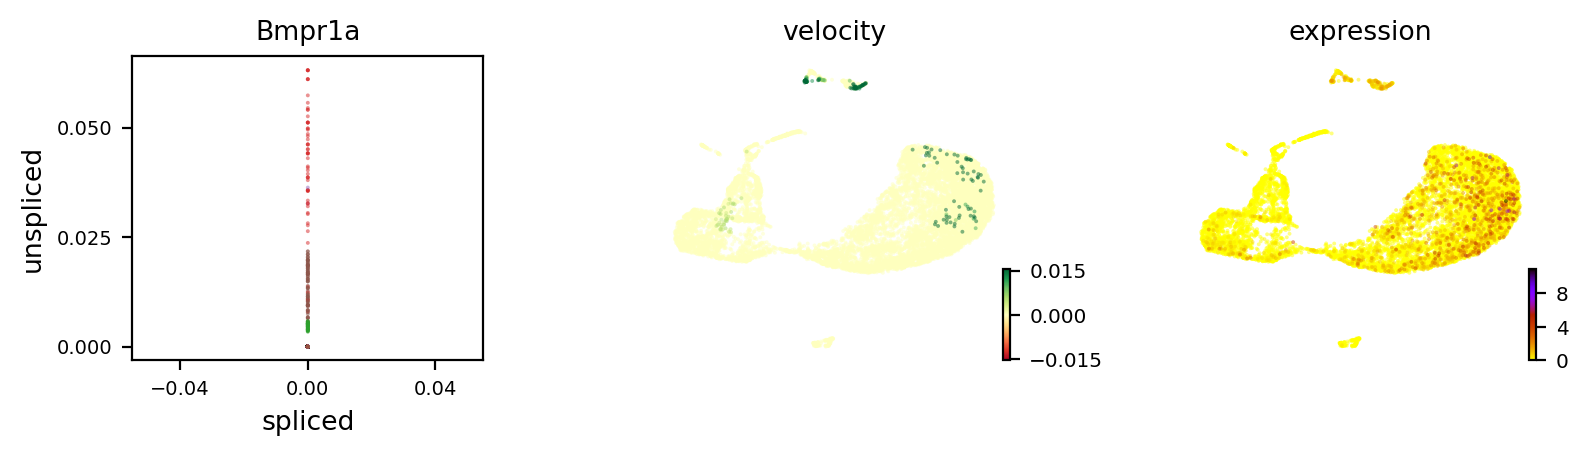

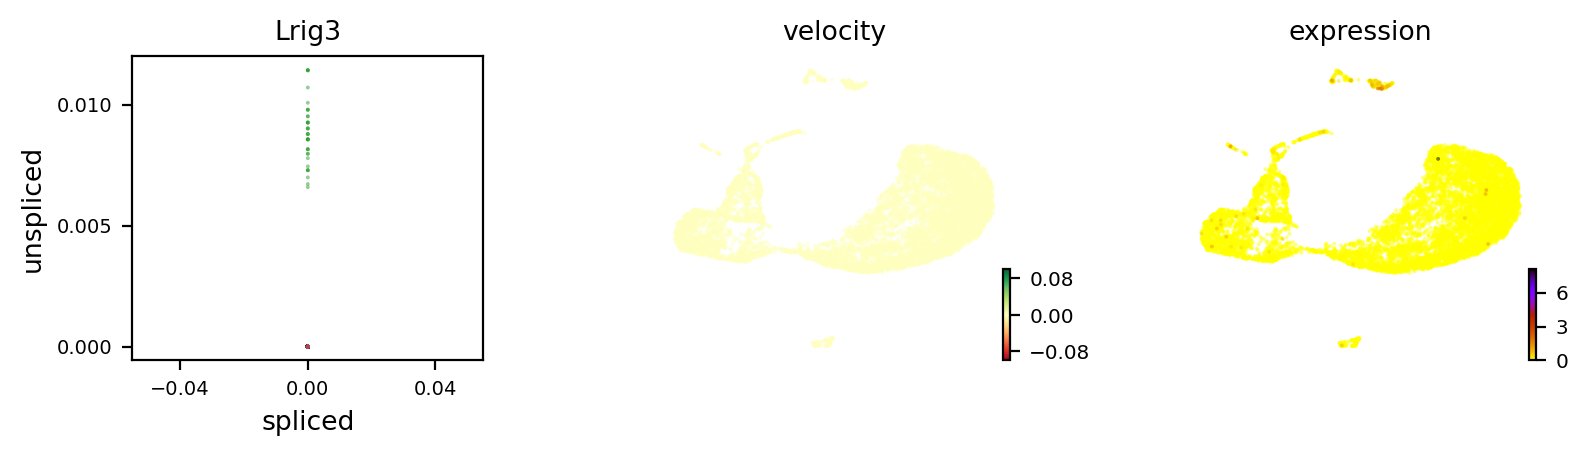

In [29]:
# plot velocity of a selected gene
scv.pl.velocity(adata, 'Bmpr1a',layers=['velocity','X'], perc=None, color='CellType')
scv.pl.velocity(adata, 'Lrig3', layers=['velocity','X'], perc=None, color='CellType')

# Downstream analysis

In [30]:
scv.tl.rank_velocity_genes(adata, groupby='CellType', min_corr=.3)

ranking velocity genes
    finished (0:00:52) --> added 
    'rank_velocity_genes', sorted scores by group ids (adata.uns) 
    'spearmans_score', spearmans correlation scores (adata.var)


In [31]:
df = scv.DataFrame(adata.uns['rank_velocity_genes']['names'])
df.head()

,MC,MONO,MP,NEUT1,NEUT2,SC
0,Atg3,Thoc1,Igf2r,Zc3h7a,Slc25a22,D030028A08Rik
1,Meak7,Vps50,Dock6,Nid1,Setd2,Dst
2,Fyn,Brix1,Atad5,Sorl1,Fbxo10,Stk3
3,Foxm1,Mob3b,Gch1,Camk1d,Ica1,Osbpl5
4,Vps4b,Plxnd1,Dnajc21,Tpd52,Atf6,Gxylt2


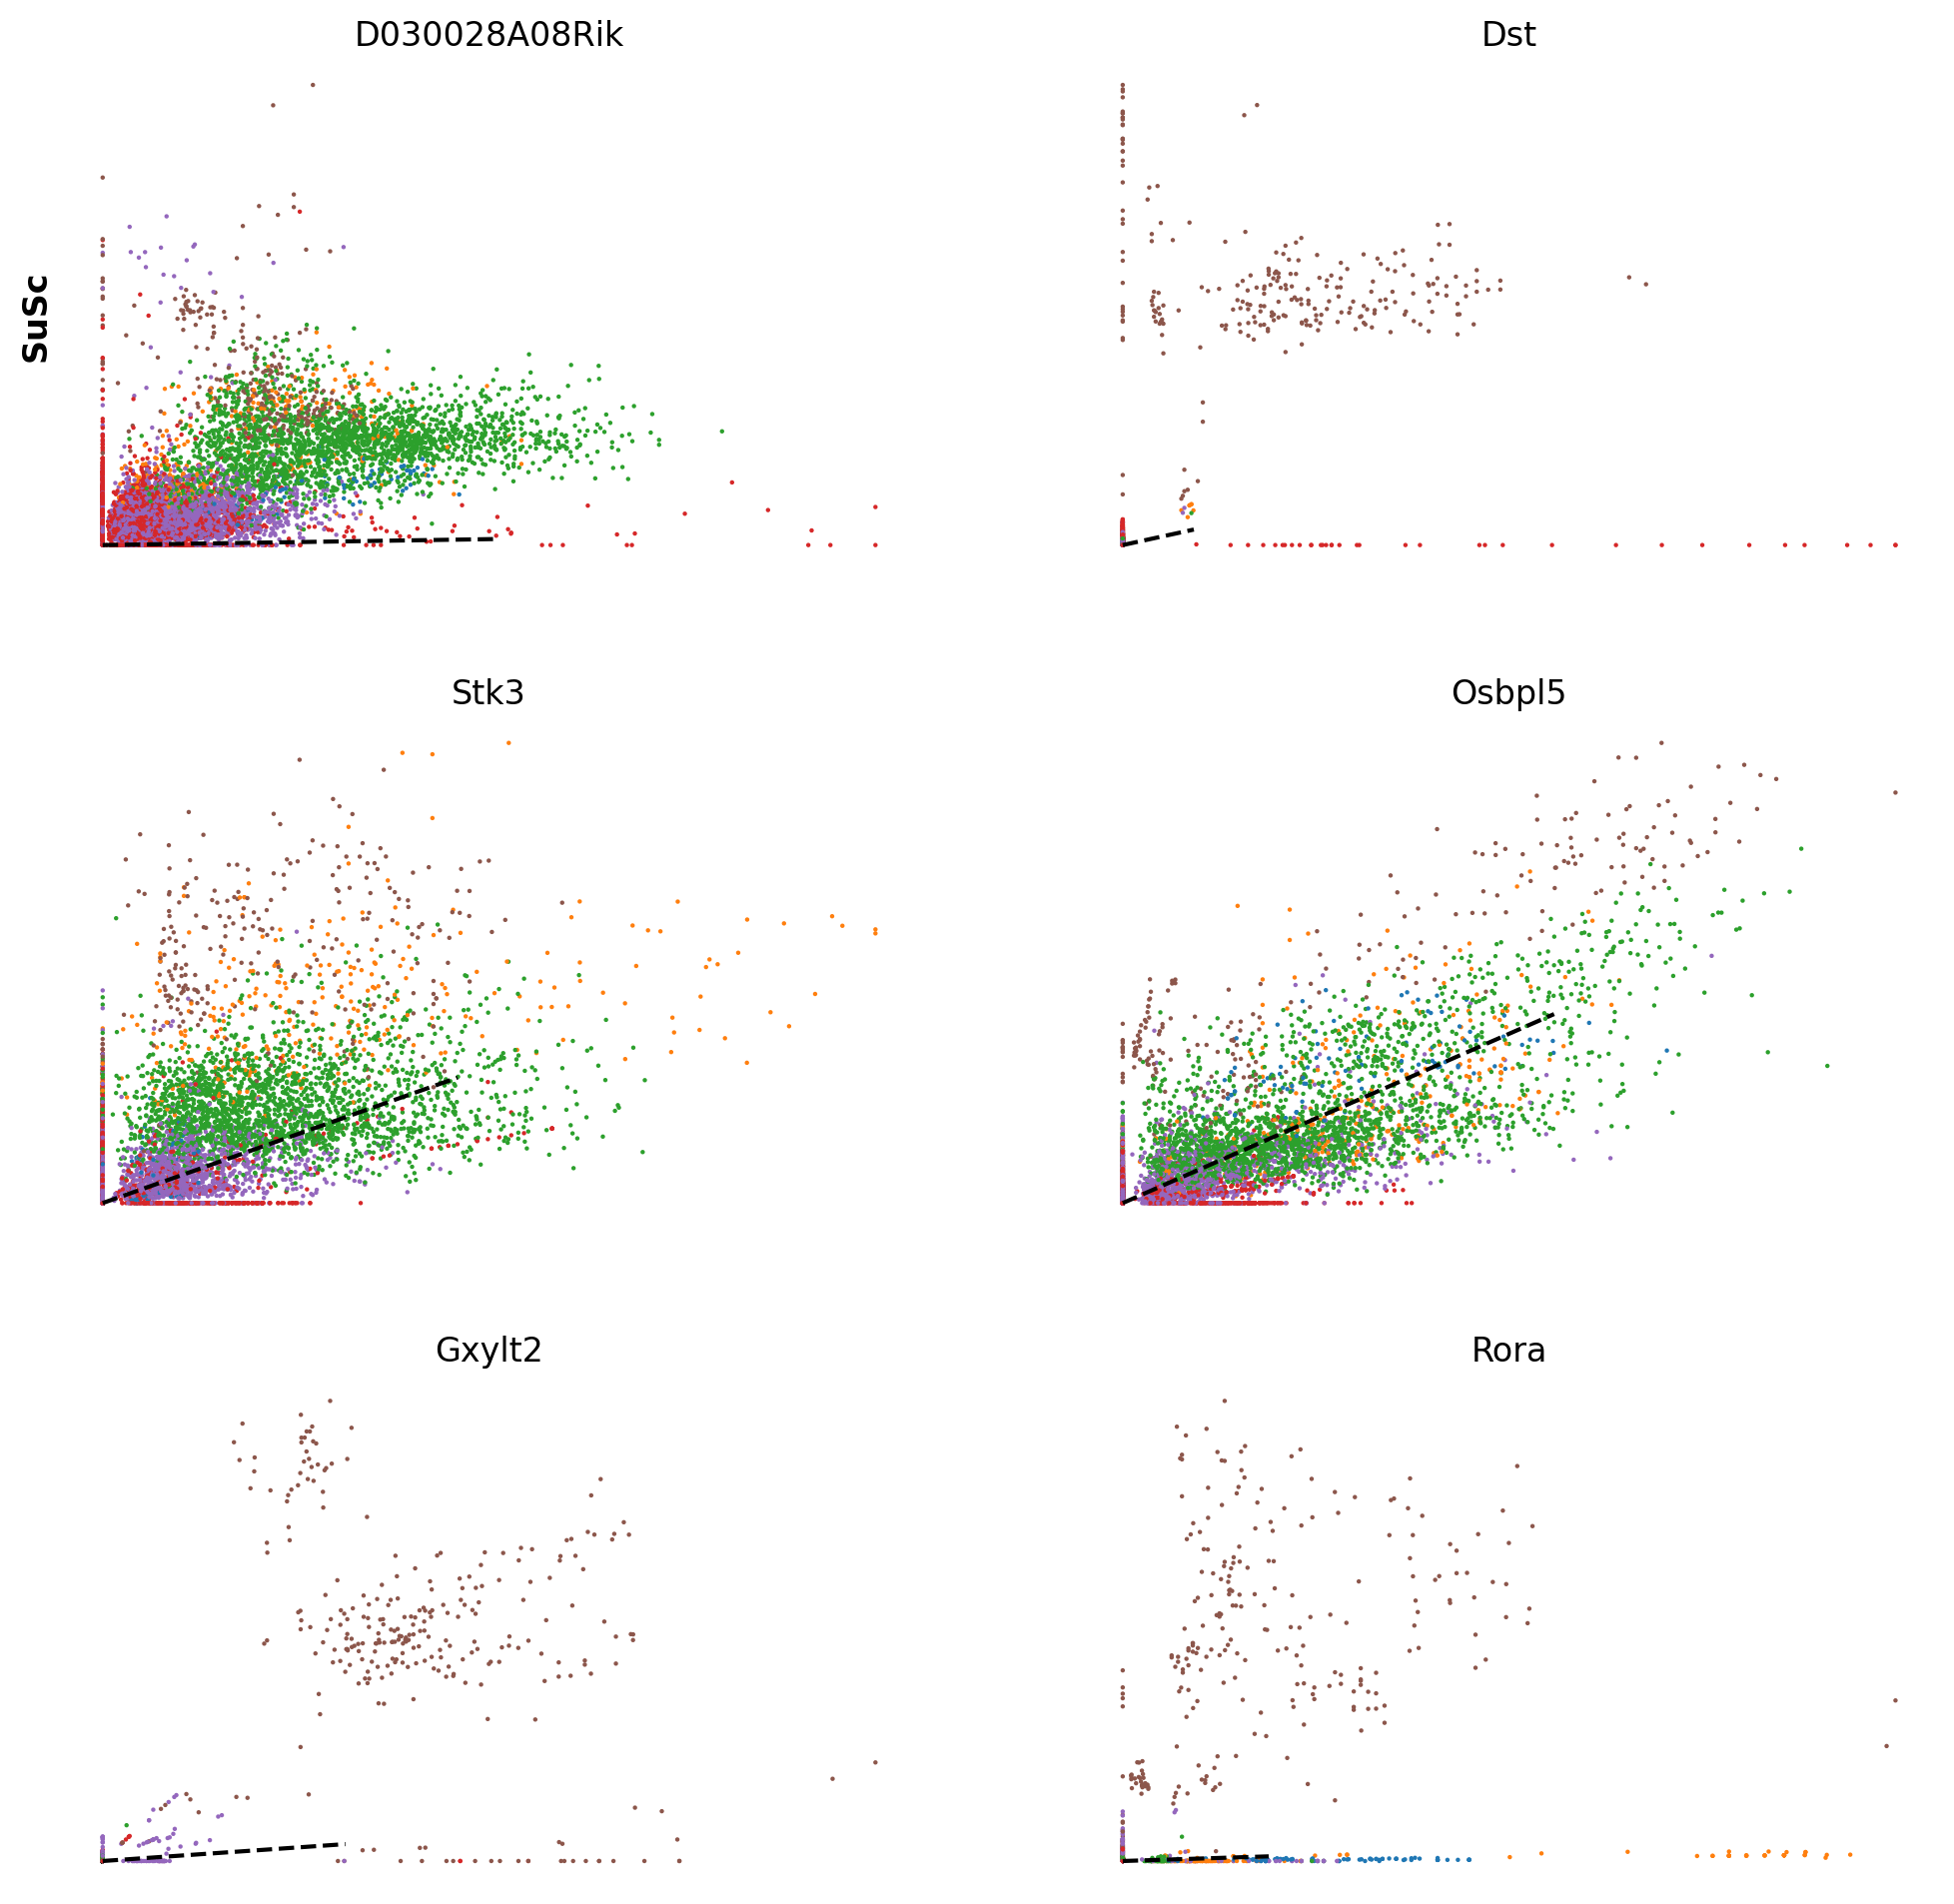

In [33]:
scv.pl.scatter(adata, df['SC'][:6], ylabel='SuSc', ncols=2, frameon=False, color='CellType', size=10, linewidth=1.5)


--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)


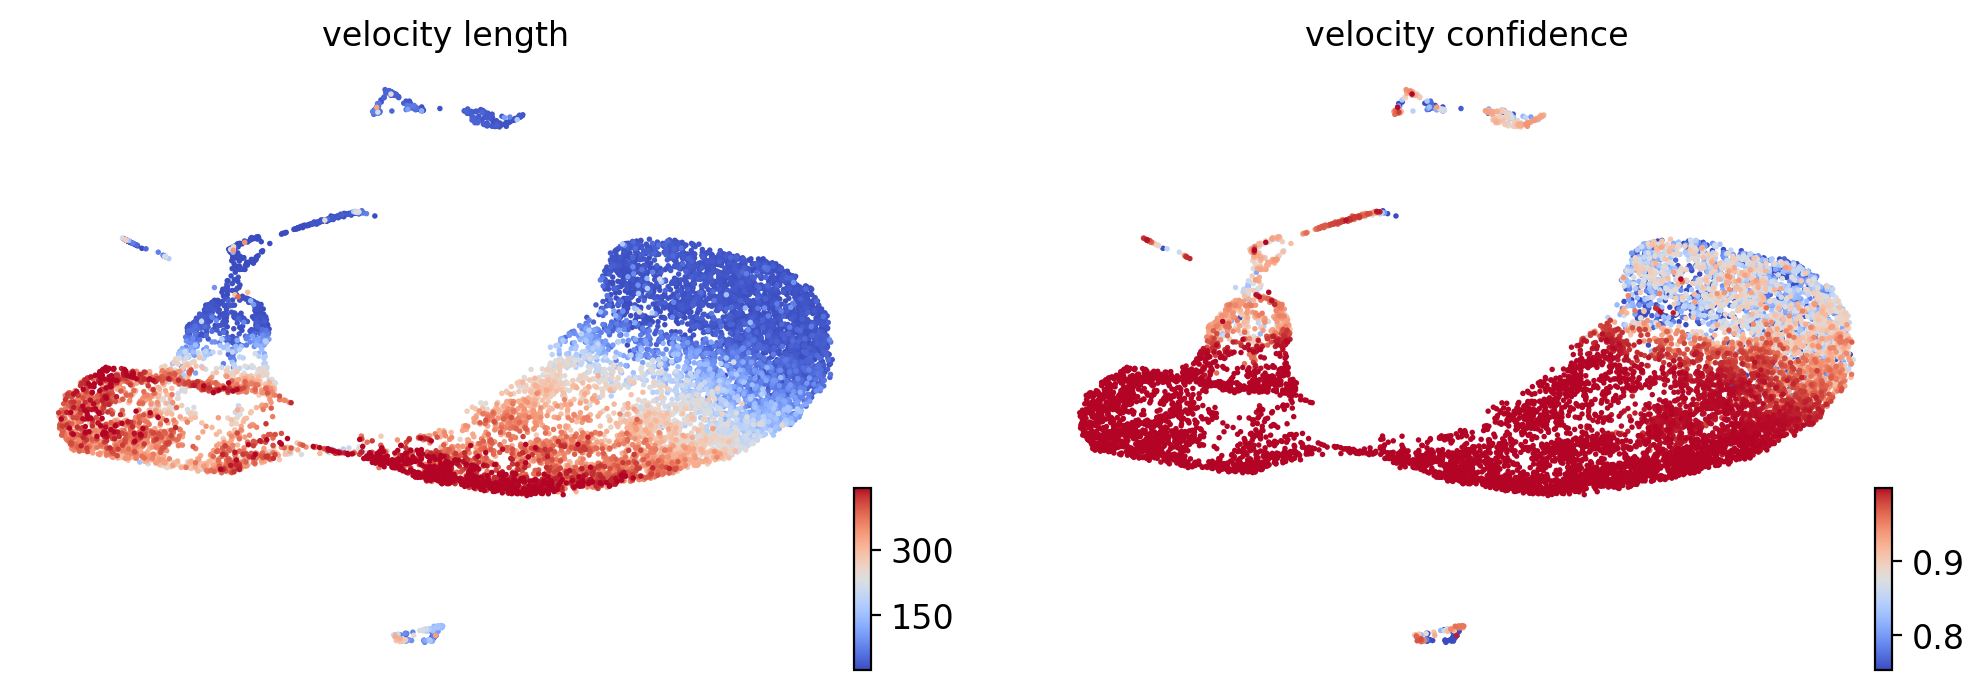

In [34]:
scv.tl.velocity_confidence(adata)
keys = 'velocity_length', 'velocity_confidence'
scv.pl.scatter(adata, c=keys, cmap='coolwarm', perc=[5, 95])

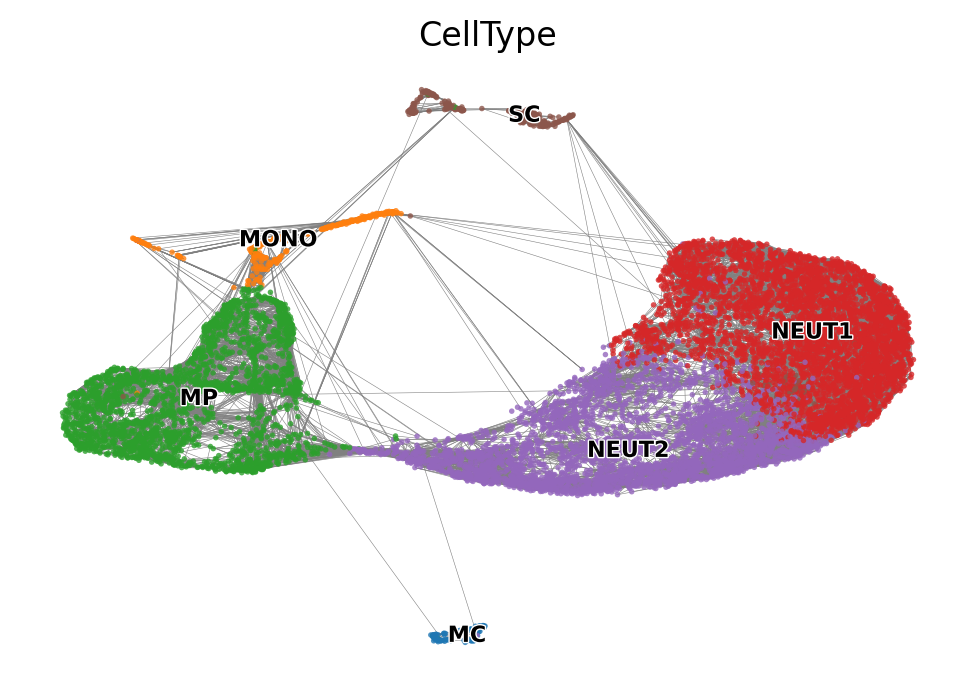

In [35]:
scv.pl.velocity_graph(adata, threshold=.1, color='CellType', legend_fontsize=8)


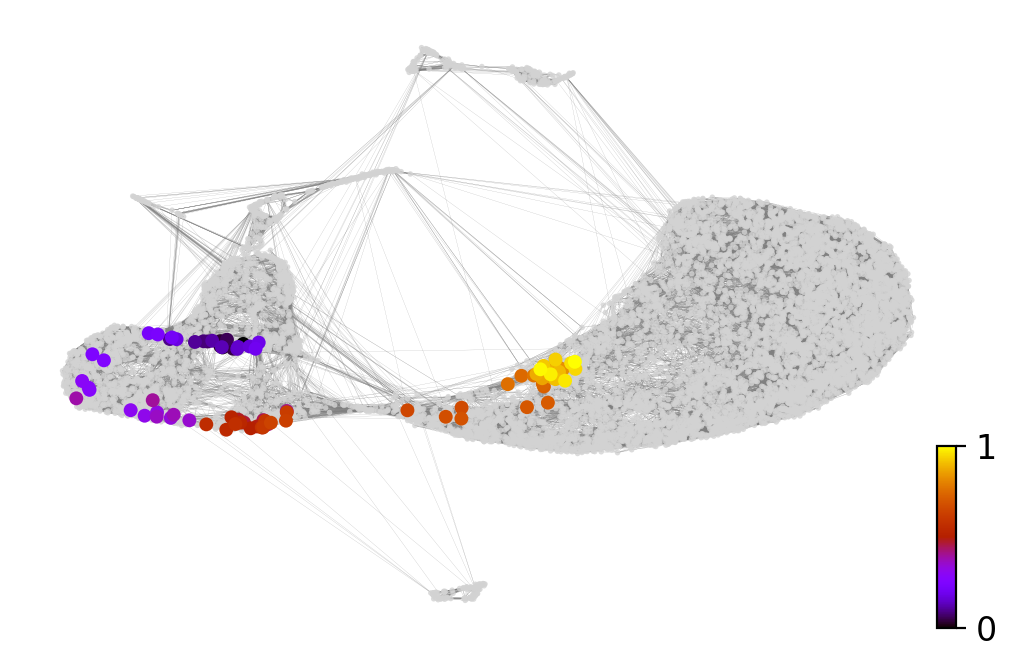

In [36]:
x, y = scv.utils.get_cell_transitions(adata, basis='umap', starting_cell=50)
ax = scv.pl.velocity_graph(adata, c='lightgrey', edge_width=.05, show=False)
ax = scv.pl.scatter(adata, x=x, y=y, s=100, c='ascending', cmap='gnuplot', ax=ax)

computing terminal states
    identified 8 regions of root cells and 1 region of end points .
    finished (0:00:01) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)


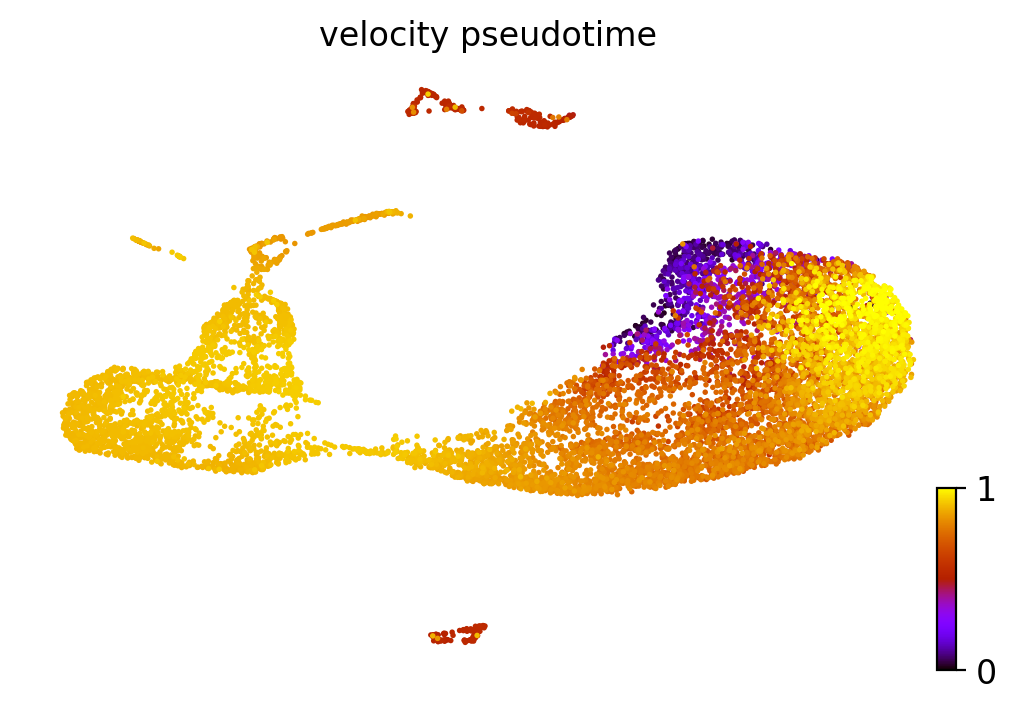

In [37]:
scv.tl.velocity_pseudotime(adata)
scv.pl.scatter(adata, color='velocity_pseudotime', cmap='gnuplot')

In [38]:
# this is needed due to a current bug - bugfix is coming soon.
adata.uns['neighbors']['distances'] = adata.obsp['distances']
adata.uns['neighbors']['connectivities'] = adata.obsp['connectivities']

In [39]:
scv.tl.paga(adata, groups='CellType')
df = scv.get_df(adata, 'paga/transitions_confidence', precision=2).T
#df.style.background_gradient(cmap='Blues').format('{:.2g}')

running PAGA using priors: ['velocity_pseudotime']
    finished (0:00:03) --> added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns)
    'paga/transitions_confidence', velocity transitions (adata.uns)


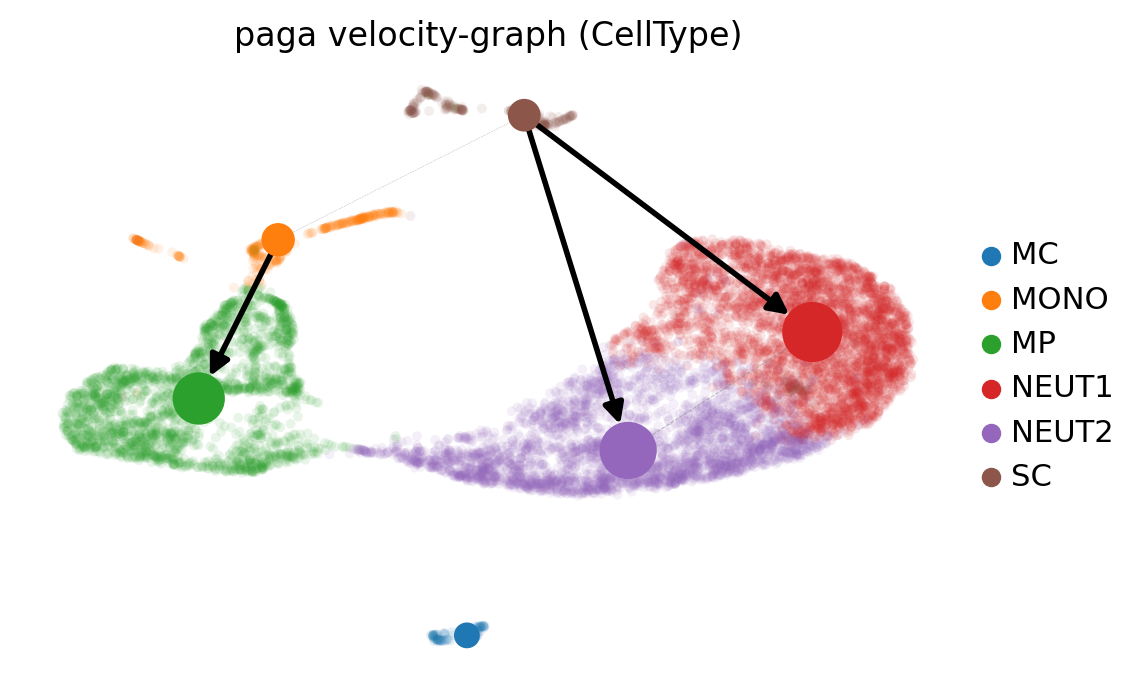

In [40]:
scv.pl.paga(adata, basis='umap', size=50, alpha=.1,
            min_edge_width=2, node_size_scale=1.5)

# Analyzing a specific cell population

In [41]:
cur_celltypes = ['SC']
adata_subset = adata[adata.obs['CellType'].isin(cur_celltypes)]

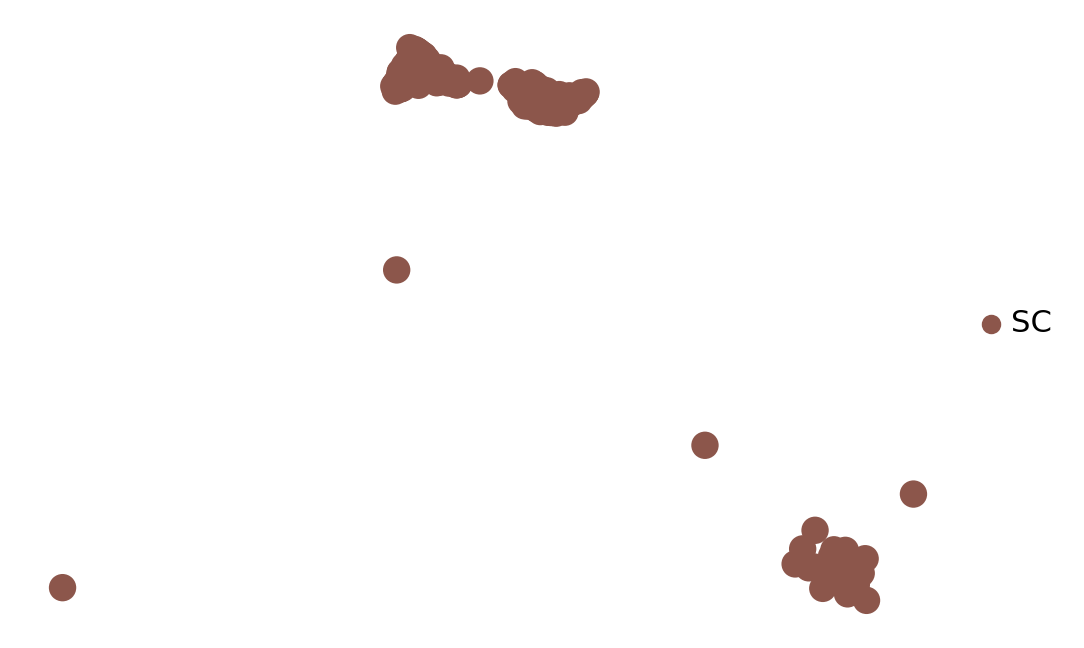

In [42]:
sc.pl.umap(adata_subset, color=['CellType'], frameon=False, title=['', ''])


In [43]:
sc.pp.neighbors(adata_subset, n_neighbors=15, use_rep='X_pca')

In [44]:
# pre-process
scv.pp.filter_and_normalize(adata_subset)
scv.pp.moments(adata_subset)

computing neighbors
    finished (0:00:00) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [45]:
scv.tl.recover_dynamics(adata_subset)

recovering dynamics (using 1/32 cores)


  0%|          | 0/1348 [00:00<?, ?gene/s]

    finished (0:02:30) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)


/home/zhj869/.conda/envs/velocyto_test/lib/python3.7/site-packages/scvelo/tools/dynamical_model.py:713: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  np.array([dm.alpha, dm.beta, dm.gamma, dm.pars[:3]]) / dm.m[-1]
/home/zhj869/.conda/envs/velocyto_test/lib/python3.7/site-packages/scvelo/tools/dynamical_model.py:716: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  np.array([dm.t, dm.tau, dm.t_, dm.pars[4]]) * dm.m[-1]


In [46]:
scv.tl.velocity(adata_subset, mode='dynamical')
scv.tl.velocity_graph(adata_subset)

computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/32 cores)


  0%|          | 0/309 [00:00<?, ?cells/s]

    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


/home/zhj869/.conda/envs/velocyto_test/lib/python3.7/site-packages/scvelo/core/_parallelize.py:138: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  res = np.array(res) if as_array else res


computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
saving figure to file ./figures/scvelo_embedding_stream.pdf


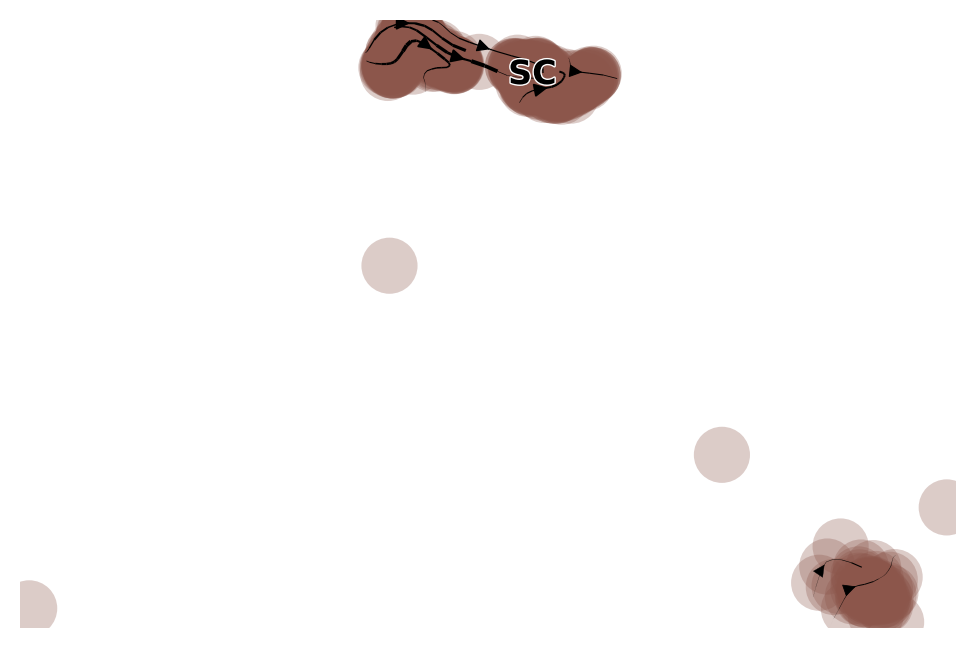

In [47]:
scv.pl.velocity_embedding_stream(adata_subset, basis='umap', color=['CellType'], save='embedding_stream.pdf', title='')


In [48]:
df = adata_subset.var
df = df[(df['fit_likelihood'] > .1) & df['velocity_genes'] == True]

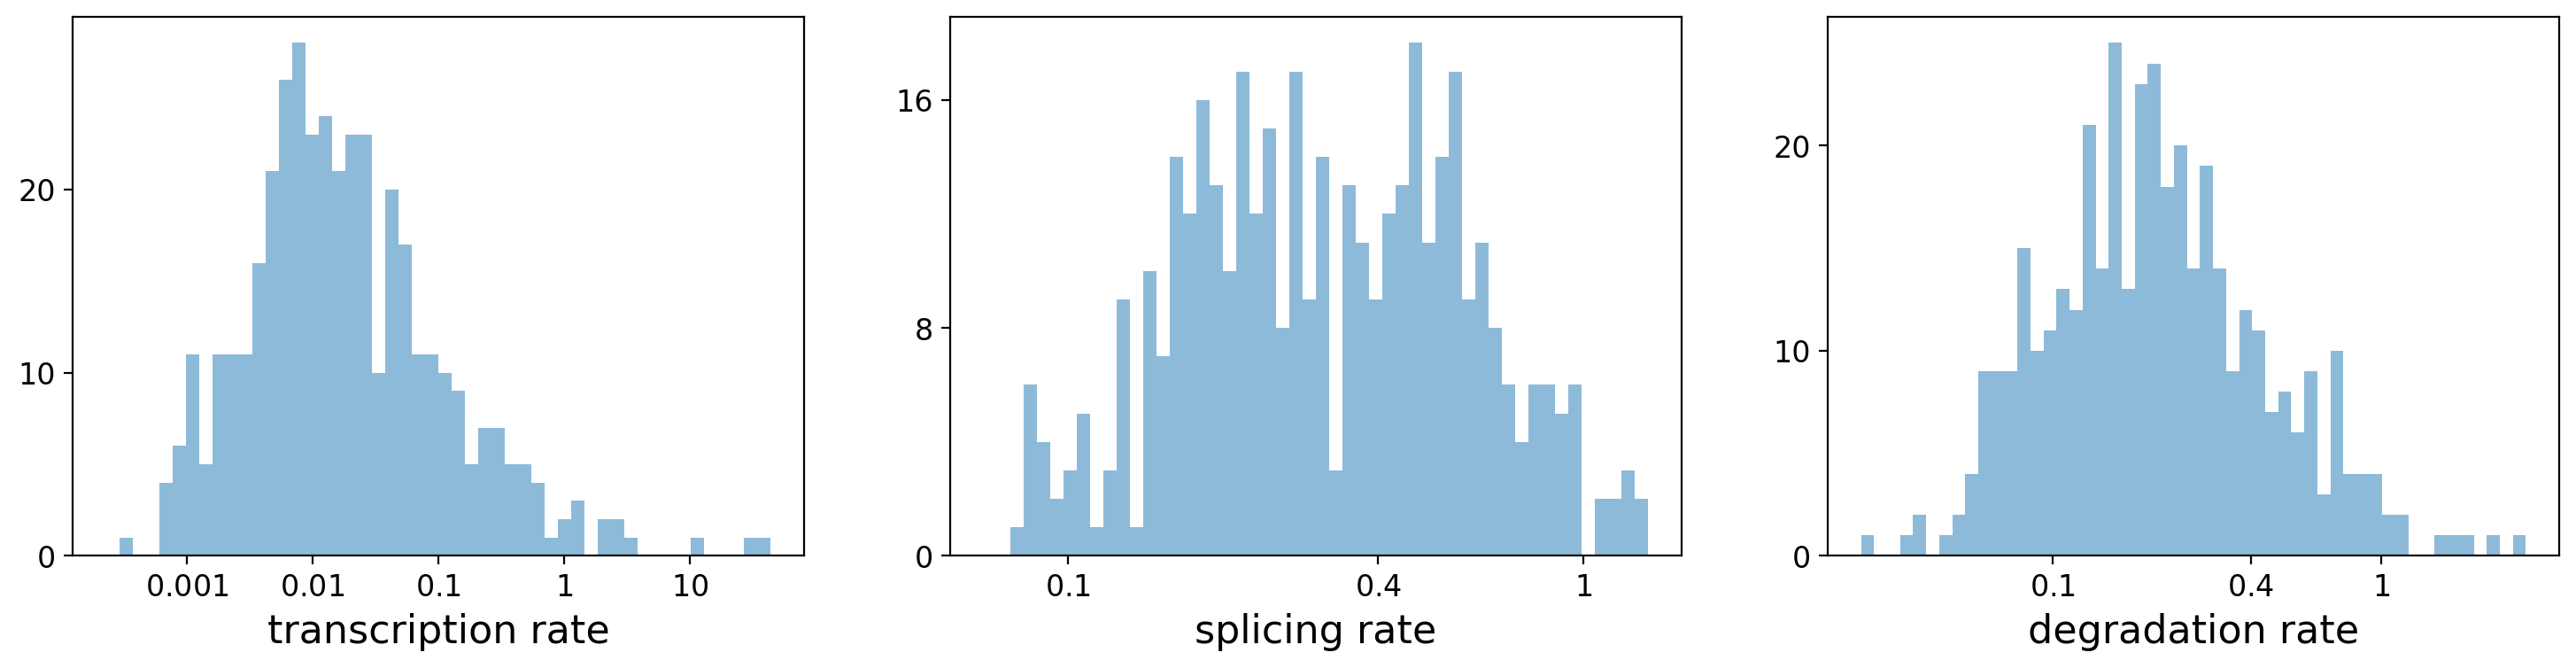

In [49]:
kwargs = dict(xscale='log', fontsize=16)
with scv.GridSpec(ncols=3) as pl:
    pl.hist(df['fit_alpha'], xlabel='transcription rate', **kwargs)
    pl.hist(df['fit_beta'] * df['fit_scaling'], xlabel='splicing rate', xticks=[.1, .4, 1], **kwargs)
    pl.hist(df['fit_gamma'], xlabel='degradation rate', xticks=[.1, .4, 1], **kwargs)

In [50]:
scv.get_df(adata_subset, 'fit*', dropna=True).head()


/home/zhj869/.conda/envs/velocyto_test/lib/python3.7/site-packages/scvelo/core/_anndata.py:311: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.var_names = df.index


,fit_alpha,fit_beta,fit_gamma,fit_t_,fit_scaling,fit_std_u,fit_std_s,fit_likelihood,fit_u0,fit_s0,fit_pval_steady,fit_steady_u,fit_steady_s,fit_variance,fit_alignment_scaling,fit_r2
Tcf24,5.50e-02,7.78e-01,0.20,10.53,0.66,0.02,5.66e-02,0.32,0.0,0.0,1.65e-01,0.07,1.36e-01,0.53,2.70,-0.01
Sulf1,1.35e-03,1.96e-03,0.11,29.46,250.58,0.31,1.83e-03,0.22,0.0,0.0,8.32e-04,0.93,1.11e-02,0.88,2.91,-0.45
Kcnq5,9.54e-04,1.79e-03,0.03,28.13,75.13,0.17,3.80e-03,0.19,0.0,0.0,9.69e-02,0.53,1.44e-02,1.45,13.49,-1.34
Fam135a,1.06e-03,7.12e-03,0.11,29.13,63.49,0.06,1.44e-03,0.21,0.0,0.0,2.70e-08,0.19,8.98e-03,1.12,3.13,-1.87
Bend6,3.28e-04,3.80e-03,0.07,24.86,112.93,0.03,4.96e-04,0.20,0.0,0.0,2.24e-03,0.12,3.48e-03,1.25,4.04,-0.75


computing latent time using root_cells as prior
    finished (0:00:00) --> added 
    'latent_time', shared time (adata.obs)


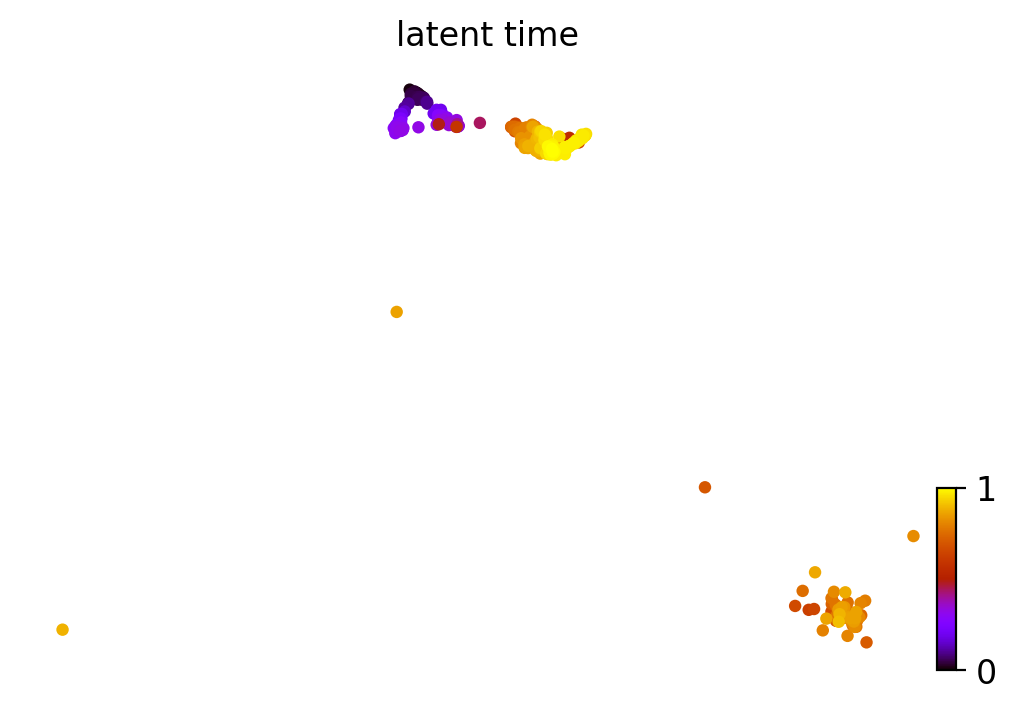

In [51]:
scv.tl.latent_time(adata_subset)
scv.pl.scatter(adata_subset, color='latent_time', color_map='gnuplot', size=80)

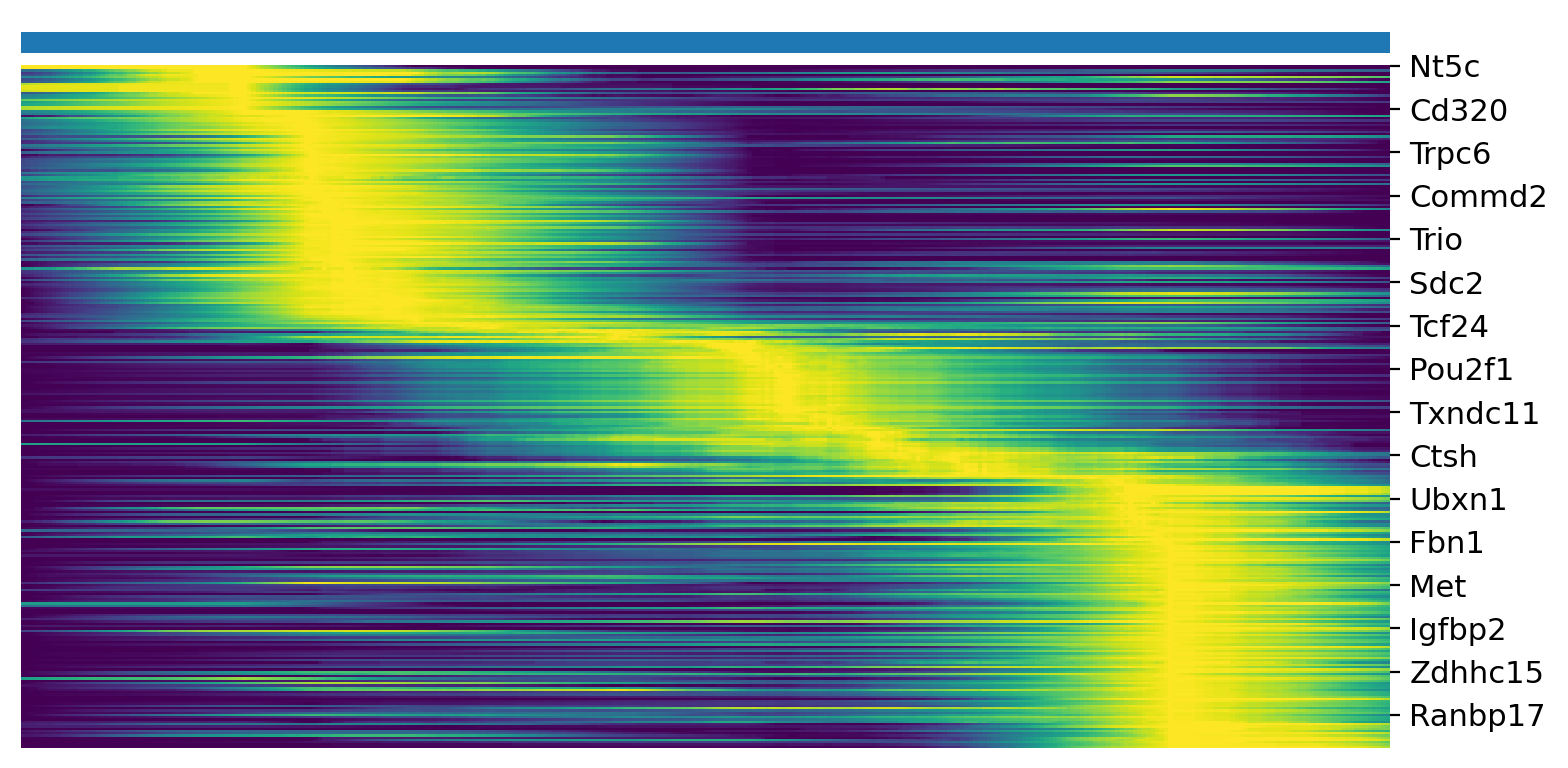

In [52]:
top_genes = adata_subset.var['fit_likelihood'].sort_values(ascending=False).index[:300]
scv.pl.heatmap(adata_subset, var_names=top_genes, sortby='latent_time', col_color='seurat_clusters', n_convolve=100)

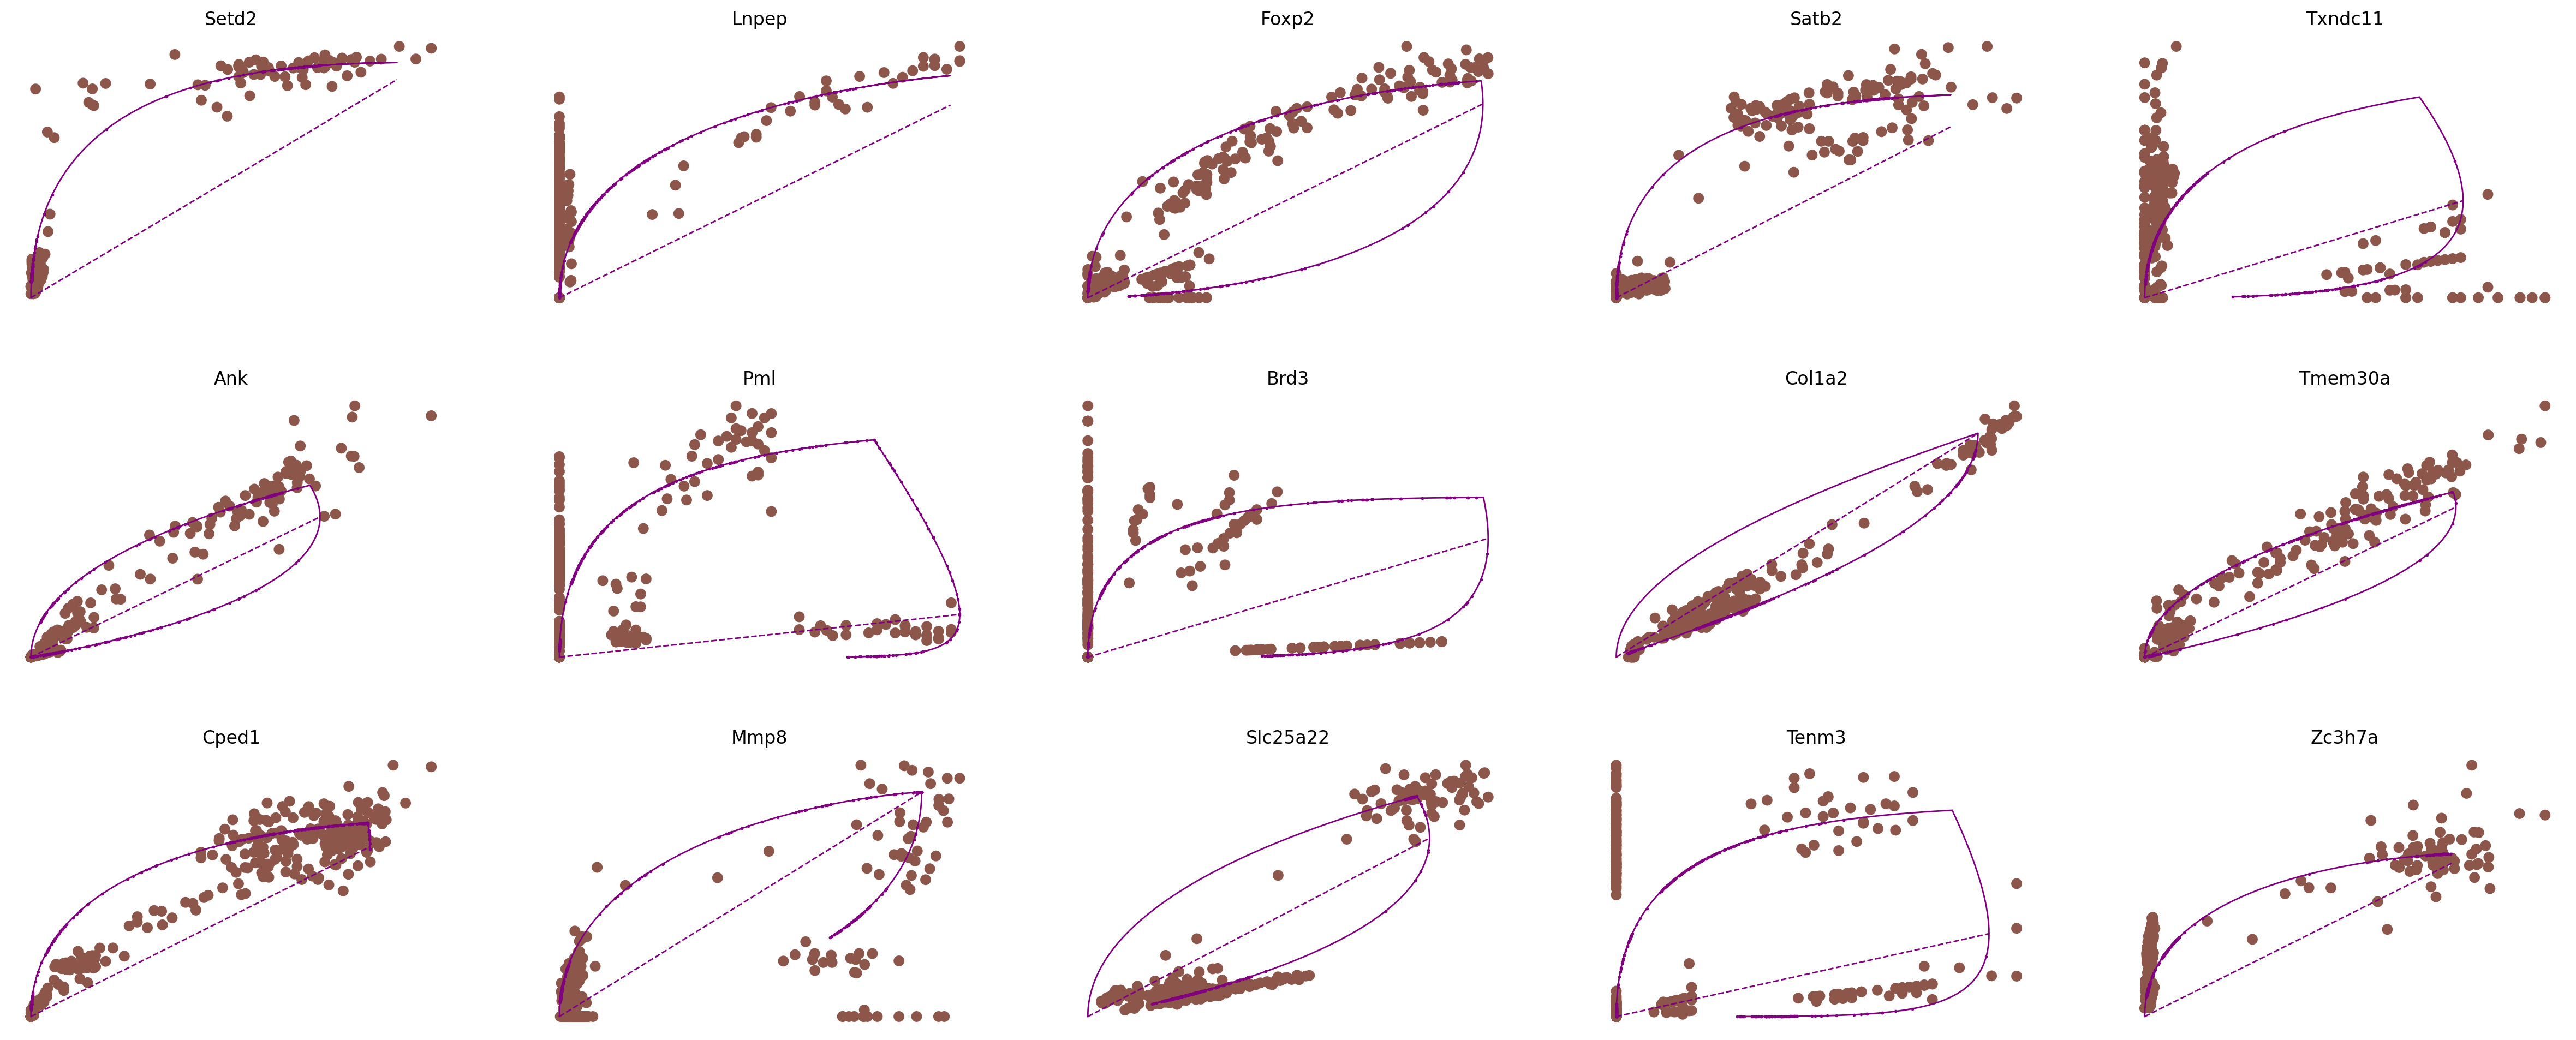

In [53]:
top_genes = adata_subset.var['fit_likelihood'].sort_values(ascending=False).index
scv.pl.scatter(adata_subset, color='CellType', basis=top_genes[:15], ncols=5, frameon=False)

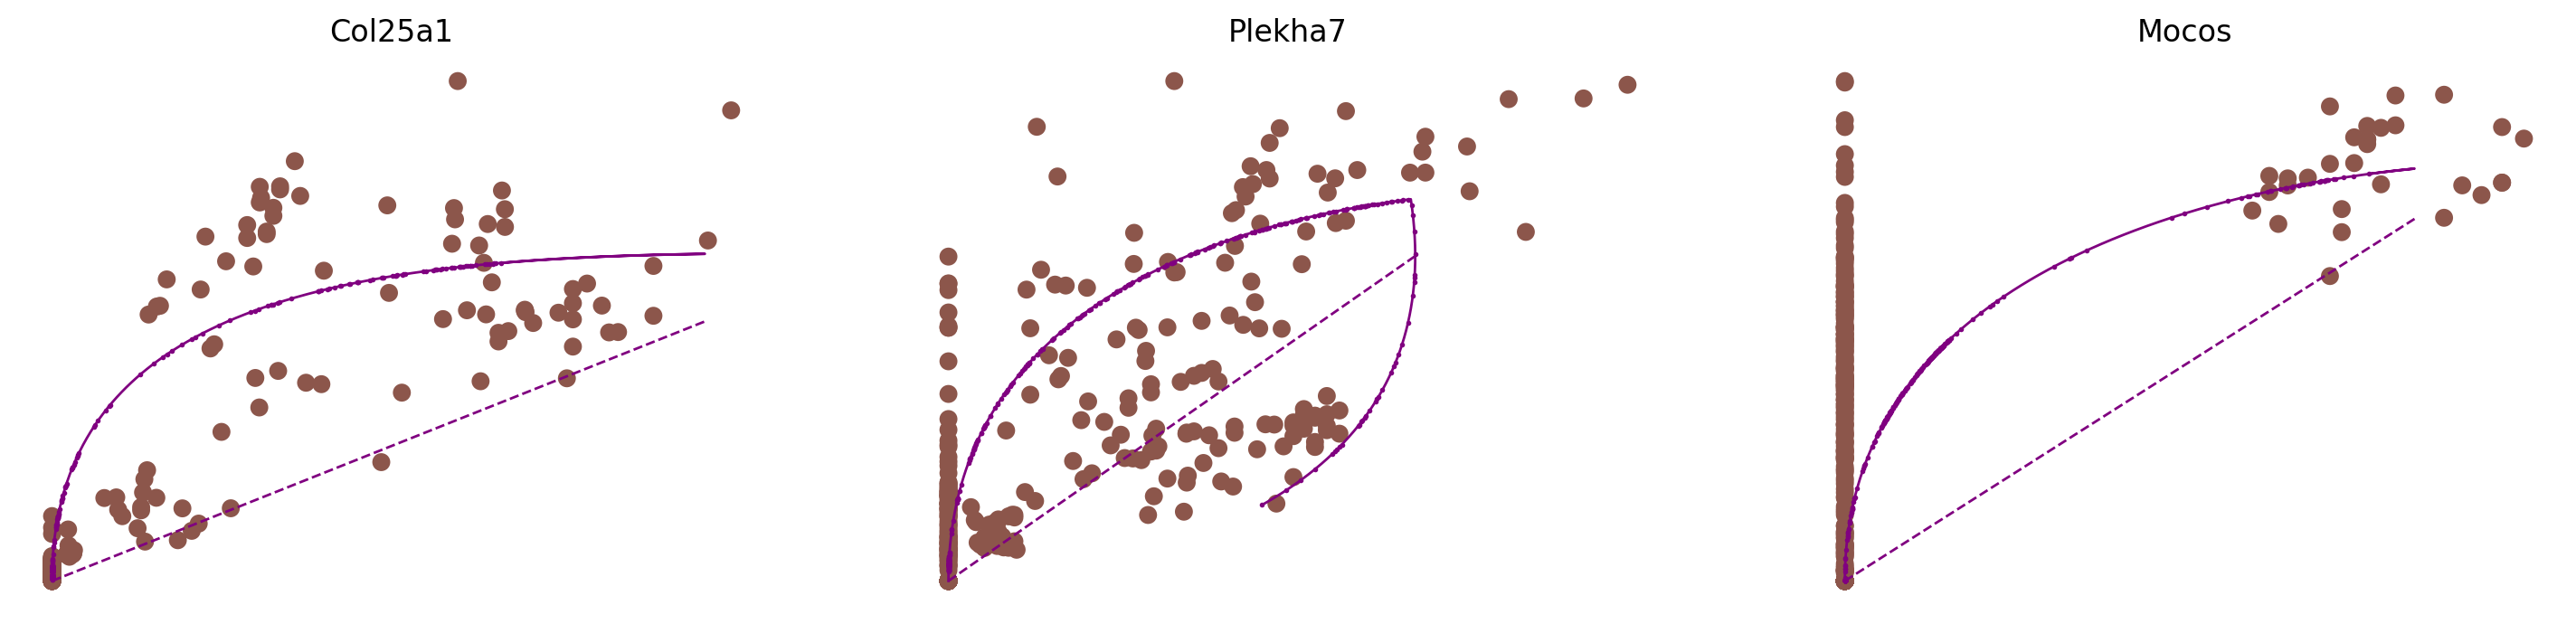

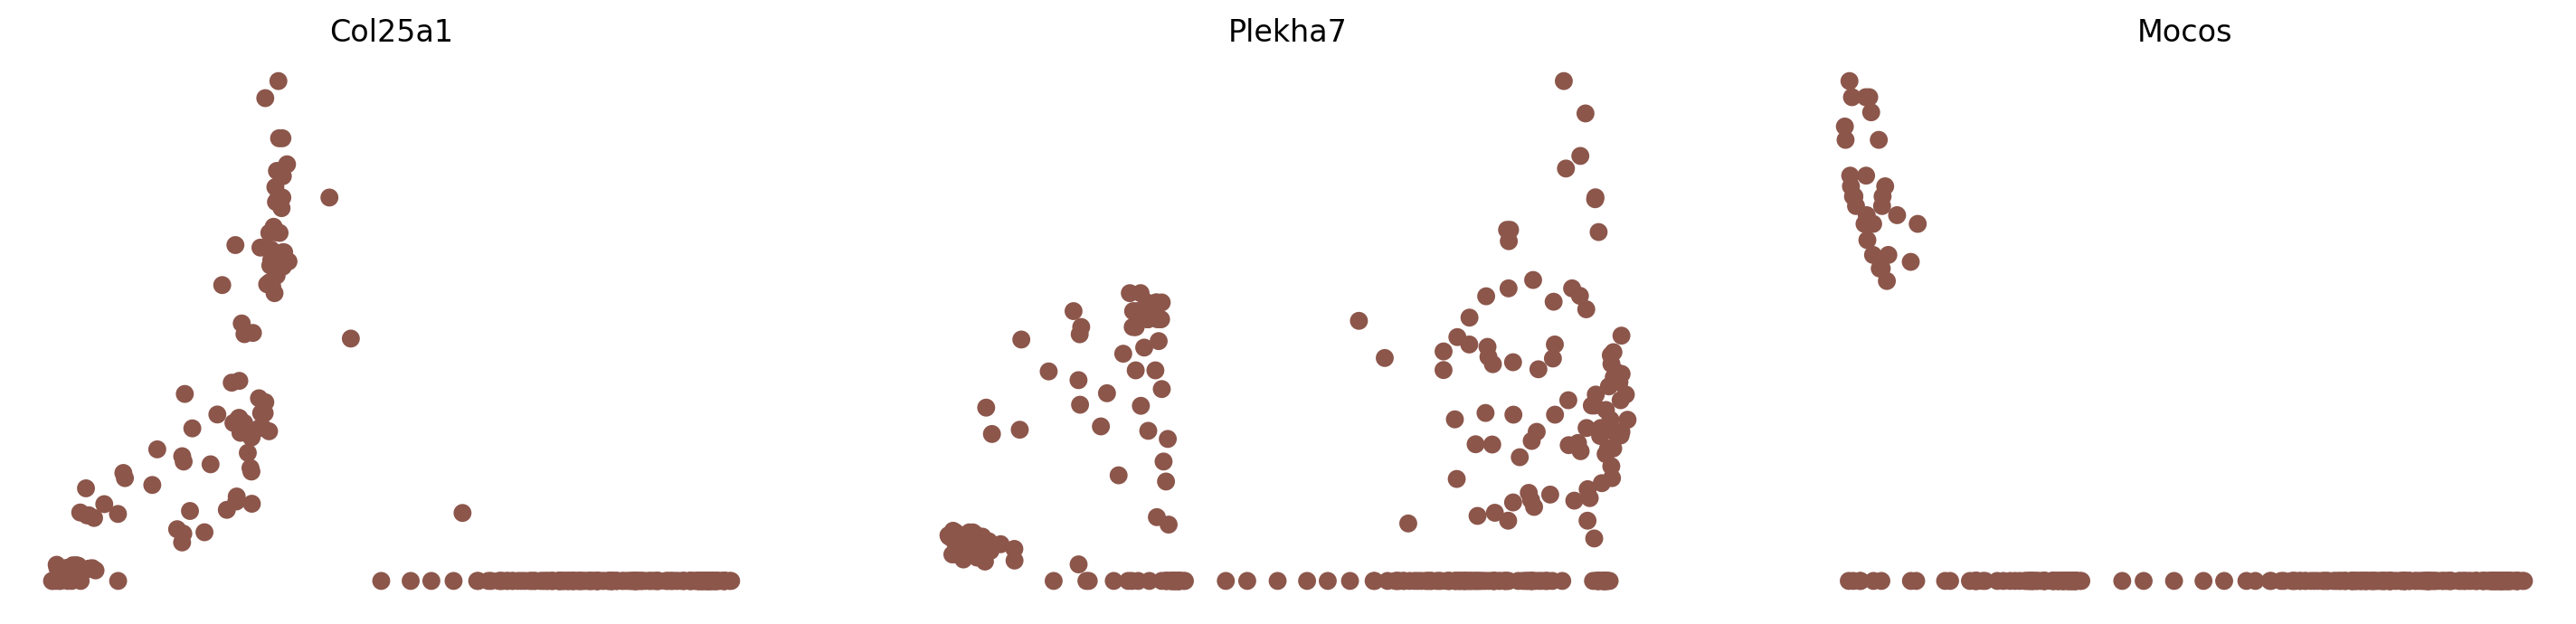

In [54]:
var_names = ['Col25a1', 'Plekha7', 'Mocos']
scv.pl.scatter(adata_subset, var_names, color='CellType', frameon=False)
scv.pl.scatter(adata_subset, x='latent_time', y=var_names, color='CellType', frameon=False)